# 6. Bayesian volatility: how sure are we, and why it matters

**What this notebook answers:** we never know the true volatility. A Bayesian keeps a whole
*range* of plausible volatilities instead of one number. What does that range look like for
Bitcoin, and how does it change the probability that a price level gets touched?

> **Data note.** Uses the local Kraken bar cache (see notebook 5); results are saved in the notebook.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np, pandas as pd, polars as pl, matplotlib.pyplot as plt
from scipy import stats
import _style as st
from pmq.crypto import ticks, vol, grid, bayes_vol, barrier, features, backtest

st.setup()
DAY = 1 / 365
bars = ticks.load_bars("../data/bars/XBT_1m.parquet")
g = grid.build_hourly_grid(bars, start="2017-01-01")
r = features.hourly_log_returns(g)

## 6.1 Belief as a distribution: the Inverse-Gamma

Say each hour's return is a bell-curve draw with unknown variance $s^2$. Our belief about $s^2$ is a
distribution. The convenient choice is the **Inverse-Gamma**, described by two numbers:

* $\alpha$ = how much evidence we hold (roughly half the number of observations),
* $\beta$ = the accumulated squared movement.

**Bayes' update is just addition.** After seeing $n$ new returns $r_i$:

$$\alpha' = \alpha + \tfrac{n}{2}, \qquad \beta' = \beta + \tfrac12\sum r_i^2 .$$

The forecast is the belief's mean, $\beta/(\alpha-1)$, and it comes with a credible range. `tests/test_bayes_vol.py` checks this against brute-force
numerical integration of "prior × likelihood".

## 6.2 Forgetting: yesterday matters more than last year

Volatility changes, so old evidence should fade. Before each update, multiply $\alpha$ and $\beta$
by a **discount** $\delta$ slightly below 1. With $\delta = 1 - 1/240$ hourly, the memory is about 10 days. Running this over two years of Bitcoin hourly returns:

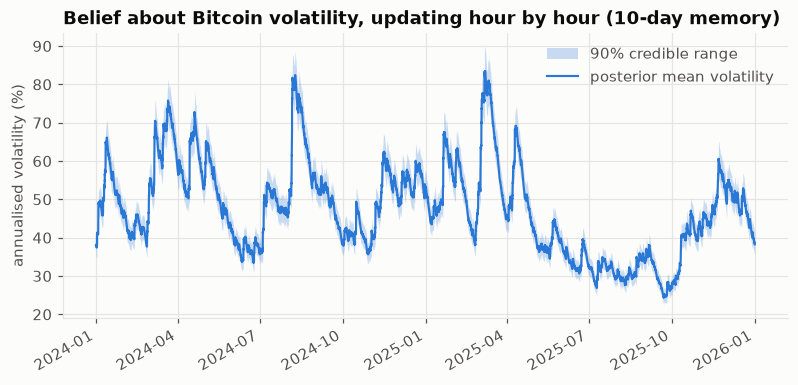

typical credible range width (points): 7.1 | effective observations: 240


In [2]:
delta = 1 - 1 / 240
prior = bayes_vol.VarianceBelief.from_annual_vol(0.6, 8760, strength=2)
alpha, beta = bayes_vol.filter_discounted(r, delta, prior)
idx = pd.date_range(pd.Timestamp(g.t0), periods=len(g), freq="h")
sel = (idx >= "2024-01-01")
tail = 0.05
lo, hi = [np.sqrt(stats.invgamma.ppf(q, alpha[sel], scale=beta[sel]) * 8760) * 100 for q in (tail, 1 - tail)]
mean = np.sqrt(beta[sel] / (alpha[sel] - 1) * 8760) * 100
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.fill_between(idx[sel], lo, hi, color=st.BLUE, alpha=0.25, lw=0, label="90% credible range")
ax.plot(idx[sel], mean, color=st.BLUE, lw=1.4, label="posterior mean volatility")
ax.set_ylabel("annualised volatility (%)"); ax.set_title("Belief about Bitcoin volatility, updating hour by hour (10-day memory)")
ax.legend(loc="upper right"); fig.autofmt_xdate(); plt.show()
print("typical credible range width (points):", round(float(np.median(hi - lo)), 1), "| effective observations:", round(2 * alpha[-1]))

The band is **narrow**: about 7 points wide. With about 240 hourly observations in memory, the *statistical* uncertainty about the volatility that generated them is small. That is a real and important finding:

> **Uncertainty about the volatility of the past is small. Uncertainty about the volatility of the future is large.** The band above answers the first; a contract needs the second.

## 6.3 A neat identity: EWMA is Bayesian updating in disguise

The industry-standard EWMA volatility (RiskMetrics) weights recent squared returns with fading weights $\lambda^k$. Bayes with forgetting
factor $\delta$ gives $\beta/\alpha$ = the same exponentially weighted average when $\lambda=\delta$. So a practitioner using EWMA is already a (very simple) Bayesian. Check on real data:

In [3]:
tiny = bayes_vol.VarianceBelief(1e-9, 1e-12)
a, b = bayes_vol.filter_discounted(r[-5000:], delta, tiny)
print("Bayes beta/alpha :", b[-1] / a[-1])
print("EWMA (lambda=delta):", vol.ewma_variance(r[-5000:], lam=delta))

Bayes beta/alpha : 1.6555489551133064e-05
EWMA (lambda=delta): 1.6555489551133057e-05


## 6.4 Is the update code right? Simulation-based calibration

How do we *know* the Bayes machinery has no bug? Simulate a world where we know the truth:
draw a true variance from the prior, generate data from it, compute the posterior, and ask **where the true value ranks among posterior draws**.
If everything is right, the rank is equally likely to be anywhere, so a histogram of ranks over thousands of trials is **flat**. A hump or a U exposes an over- or under-confident posterior.
We also run it on a deliberately broken update (it double-counts data) to prove the test can fail:

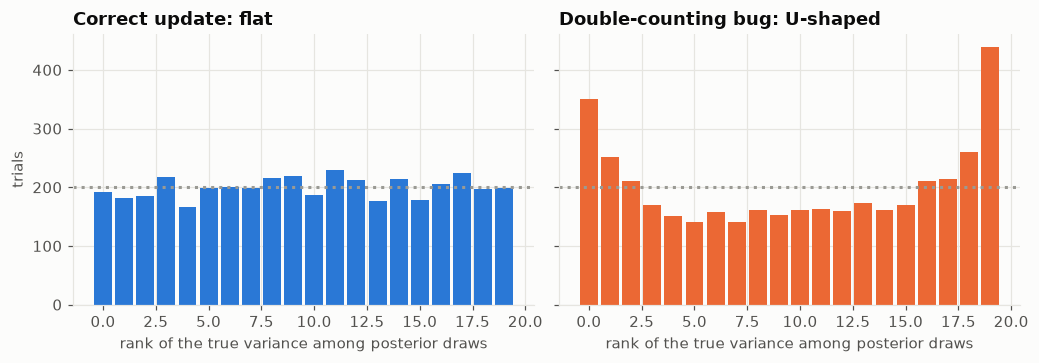

In [4]:
class Overconfident(bayes_vol.VarianceBelief):
    def update(self, returns):
        x = np.asarray(returns, dtype=float)
        return Overconfident(self.alpha + x.size, self.beta + float(np.sum(x**2)))

good = bayes_vol.simulation_based_calibration(bayes_vol.VarianceBelief(4.0, 0.003), 25, 4000, 19, seed=1)
bad = bayes_vol.simulation_based_calibration(Overconfident(4.0, 0.003), 25, 4000, 19, seed=2)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
for ax, ranks, title, colour in [(axes[0], good, "Correct update: flat", st.BLUE), (axes[1], bad, "Double-counting bug: U-shaped", st.ORANGE)]:
    ax.bar(np.arange(20), np.bincount(ranks, minlength=20), color=colour, width=0.85)
    ax.axhline(4000 / 20, color=st.GREY, ls=":"); ax.set_title(title); ax.set_xlabel("rank of the true variance among posterior draws")
axes[0].set_ylabel("trials")
plt.tight_layout(); plt.show()

## 6.5 Why uncertainty raises far-out probabilities (Jensen's inequality)

Take a barrier far above today's price. The touch probability, as a function of the volatility, is **convex**: it is flat when volatility is low
(no chance either way), then accelerates. Averaging a convex curve over uncertainty gives more than the curve at the average, just as the
average of a bendy seesaw's heights sits above the height at its midpoint. The curve for three barriers:

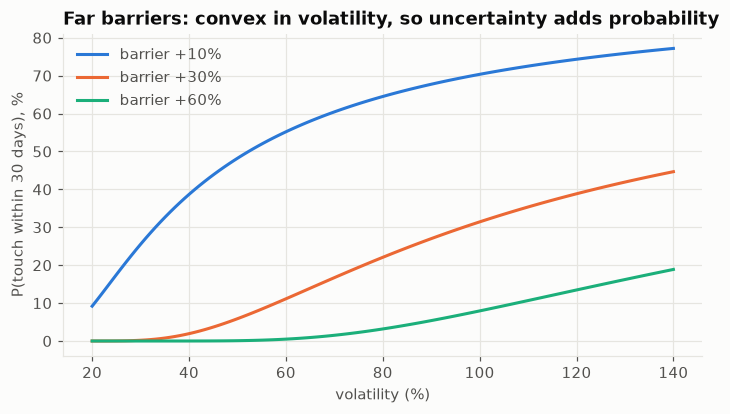

In [5]:
sig = np.linspace(0.2, 1.4, 120)
fig, ax = plt.subplots()
for pct, colour in [(10, st.BLUE), (30, st.ORANGE), (60, st.AQUA)]:
    ax.plot(sig * 100, barrier.touch_probability(100.0, 100 * (1 + pct / 100), sig, 30 * DAY) * 100, color=colour, label=f"barrier +{pct}%")
ax.set_xlabel("volatility (%)"); ax.set_ylabel("P(touch within 30 days), %"); ax.set_title("Far barriers: convex in volatility, so uncertainty adds probability")
ax.legend(loc="upper left"); plt.show()

Now put numbers on it. The table compares the **plug-in** probability (pretend volatility is exactly the estimate) with the **posterior
predictive** (average over a belief), for a belief centred on 60% volatility held with different strength:

In [6]:
rows = []
for strength in (20, 100, 1000, 20000):
    belief = bayes_vol.VarianceBelief.from_annual_vol(0.6, 365, strength)
    for pct in (10, 30, 60):
        pt = bayes_vol.posterior_touch_probability(belief, 365, 100.0, 100 * (1 + pct / 100), 30 * DAY)
        rows.append({"evidence (obs)": strength, "barrier": f"+{pct}%", "plug-in %": pt.plug_in * 100, "averaged over belief %": pt.mean * 100,
                     "uplift (relative)": pt.mean / pt.plug_in - 1})
pd.DataFrame(rows).set_index(["evidence (obs)", "barrier"]).round(3)

plug-in %  averaged over belief %  uplift (relative)
evidence (obs) barrier                                                      
20             +10%        58.671                  57.350             -0.023
               +30%        14.666                  14.054             -0.042
               +60%         1.060                   1.326              0.251
100            +10%        55.900                  55.630             -0.005
               +30%        11.802                  11.714             -0.007
               +60%         0.583                   0.630              0.080
1000           +10%        55.256                  55.223             -0.001
               +30%        11.195                  11.181             -0.001
               +60%         0.504                   0.508              0.007
20000          +10%        55.188                  55.185             -0.000
               +30%        11.132                  11.130             -0.000
               +60%         0.496                   0.496             -0.000

With little evidence (20 observations) a +60% barrier is worth **25% more** than the plug-in says, and the gap closes as evidence
grows. Notice the sign flips for nearby barriers: at +10% and +30% the average is slightly *lower*, because in that region the curve
bends the other way (concave). So uncertainty **raises long shots and trims near-the-money probabilities**, and the effect is largest
exactly where these contracts trade cheaply (long shots).

## 6.6 The uncertainty that actually matters: tomorrow's volatility

Section 6.2 showed that uncertainty about the *past* volatility is tiny. But a contract lasting 7 or 30 days depends on the
*future* average variance, which differs from any forecast. We can measure how much directly: for every day since 2022, compare the variance
that **actually happened** over the next $h$ days with the **log-HAR forecast** made beforehand (fitted only on earlier years).

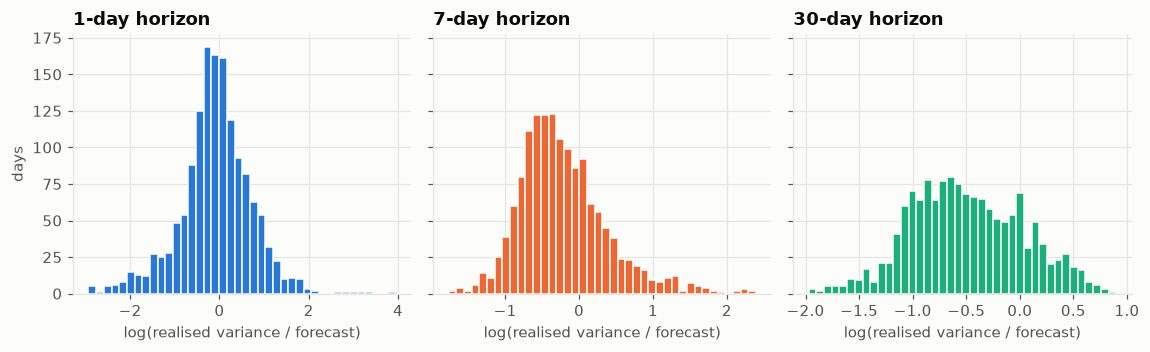

,std of log error,in vol terms (multiplier 1 std up),mean log error (out-of-sample)
horizon (days),,,
1,0.799,1.491,-0.081
7,0.597,1.348,-0.210
30,0.522,1.299,-0.495


In [7]:
cfg = backtest.BacktestConfig()
f = features.build_features(g)
cut = backtest._cutoff_index(g, 2022)
csum = np.concatenate([[0.0], np.cumsum(g.rv)])
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3), sharey=True)
stats_rows = []
for ax, d, colour in zip(axes, (1, 7, 30), (st.BLUE, st.ORANGE, st.AQUA)):
    fit = backtest.fit_har(g, f, d, cut)
    anchors = np.arange(cut, len(g) - 24 * d, 24)
    pred = backtest._har_design(f, anchors) @ fit.coef
    real = np.log((csum[anchors + 24 * d] - csum[anchors]) / d)
    err = real - pred
    ax.hist(err, bins=40, color=colour, edgecolor=st.SURFACE)
    ax.set_title(f"{d}-day horizon"); ax.set_xlabel("log(realised variance / forecast)")
    stats_rows.append({"horizon (days)": d, "std of log error": err.std(), "in vol terms (multiplier 1 std up)": np.exp(err.std() / 2), "mean log error (out-of-sample)": err.mean()})
axes[0].set_ylabel("days")
plt.tight_layout(); plt.show()
pd.DataFrame(stats_rows).set_index("horizon (days)").round(3)

The forecast error is **large**: realised variance is typically off by a factor of 1.7 to 2.2 (a standard deviation of 0.5 to 0.8 in logs), which is a **30-50% error in volatility itself**, and it is biggest for the shortest horizon.
The average error is negative here because this single fit used data up to 2021 and the market calmed down afterwards (the backtest refits every January). That spread is the **volatility of volatility** and it is the real uncertainty in a barrier contract. The backtest's `har_mix` model uses it directly:

1. Forecast the log-variance with log-HAR (median).
2. Treat the forecast error as normal in logs, with the standard deviation measured *on training data only*.
3. Average the barrier formula over 15 points of that distribution (Gauss–Hermite quadrature).

This is an *empirical-Bayes* mixture: the "prior" over future variance is learned from history. The next block shows how much it changes a real quote, using
the last day of the data (31 Dec 2025) and a 7-day horizon. Near the money the mixture is *lower* than the plug-in: the plug-in uses the **mean** variance,
which is pulled up by rare storms, while the typical week is calmer. Far out the mixture is *higher*: a 20% touch needs a storm, and storms are possible.

In [8]:
i = len(g) - 1
s0 = g.close[i]
fit7 = backtest.fit_har(g, f, 7, len(g) - 24 * 7)
log_med = float((backtest._har_design(f, np.array([i])) @ fit7.coef)[0])
nodes, qw = backtest._quadrature(15)
rows = []
for pct in (3, 5, 8, 12, 20):
    k = s0 * (1 + pct / 100)
    plug = float(barrier.touch_probability(s0, k, np.sqrt(np.exp(log_med + fit7.resid_std**2 / 2) * 365), 7 * DAY, 0.0, barrier.MINUTE_YEARS))
    mix = float(np.sum(qw * barrier.touch_probability(s0, k, np.sqrt(np.exp(log_med + fit7.resid_std * nodes) * 365), 7 * DAY, 0.0, barrier.MINUTE_YEARS)))
    rows.append({"barrier": f"+{pct}%  (${k:,.0f})", "plug-in %": plug * 100, "with volatility uncertainty %": mix * 100})
print(f"BTC at ${s0:,.0f}; forecast vol {np.sqrt(np.exp(log_med) * 365) * 100:.0f}% (median), forecast-error std {fit7.resid_std:.2f} in log variance")
pd.DataFrame(rows).set_index("barrier").round(2)

BTC at $87,500; forecast vol 37% (median), forecast-error std 0.67 in log variance


,plug-in %,with volatility uncertainty %
barrier,,
"+3% ($90,125)",58.90,53.43
"+5% ($91,875)",37.67,32.47
"+8% ($94,500)",16.61,14.56
"+12% ($98,000)",4.24,4.91
"+20% ($105,000)",0.12,0.63


## Recap

* The **Inverse-Gamma** belief updates by addition; forgetting keeps it responsive; **EWMA is the same thing** in disguise.
* The update code is validated by **simulation-based calibration** (flat ranks); a deliberately broken version fails it.
* For Bitcoin, uncertainty about *past* volatility is small (about 7 points) but about *future* volatility is large (a 30–50% error).
* Because far-out touch probabilities are convex in volatility, that uncertainty **raises** them (Jensen) and trims near-the-money ones; the effect is biggest for long shots.
* The backtest exploits this with a log-normal mixture whose spread is measured on training data.